# **Project: Amazon Product Recommendation System**

# **Marks: 40**


Welcome to the project on Recommendation Systems. We will work with the Amazon product reviews dataset for this project. The dataset contains ratings of different electronic products. It does not include information about the products or reviews to avoid bias while building the model.

--------------
## **Context:**
--------------

Today, information is growing exponentially with volume, velocity and variety throughout the globe. This has lead to information overload, and too many choices for the consumer of any business. It represents a real dilemma for these consumers and they often turn to denial. Recommender Systems are one of the best tools that help recommending products to consumers while they are browsing online. Providing personalized recommendations which is most relevant for the user is what's most likely to keep them engaged and help business.

E-commerce websites like Amazon, Walmart, Target and Etsy use different recommendation models to provide personalized suggestions to different users. These companies spend millions of dollars to come up with algorithmic techniques that can provide personalized recommendations to their users.

Amazon, for example, is well-known for its accurate selection of recommendations in its online site. Amazon's recommendation system is capable of intelligently analyzing and predicting customers' shopping preferences in order to offer them a list of recommended products. Amazon's recommendation algorithm is therefore a key element in using AI to improve the personalization of its website. For example, one of the baseline recommendation models that Amazon uses is item-to-item collaborative filtering, which scales to massive data sets and produces high-quality recommendations in real-time.

----------------
## **Objective:**
----------------

You are a Data Science Manager at Amazon, and have been given the task of building a recommendation system to recommend products to customers based on their previous ratings for other products. You have a collection of labeled data of Amazon reviews of products. The goal is to extract meaningful insights from the data and build a recommendation system that helps in recommending products to online consumers.

-----------------------------
## **Dataset:**
-----------------------------

The Amazon dataset contains the following attributes:

- **userId:** Every user identified with a unique id
- **productId:** Every product identified with a unique id
- **Rating:** The rating of the corresponding product by the corresponding user
- **timestamp:** Time of the rating. We **will not use this column** to solve the current problem

**Note:** The code has some user defined functions that will be usefull while making recommendations and measure model performance, you can use these functions or can create your own functions.

Sometimes, the installation of the surprise library, which is used to build recommendation systems, faces issues in Jupyter. To avoid any issues, it is advised to use **Google Colab** for this project.

Let's start by mounting the Google drive on Colab.

In [1]:
# !pip uninstall numpy -y

In [2]:
# !pip install numpy==1.26.0

**Note:** A pop-up will appear prompting you to restart the session. Please click on it, and then begin running the notebook from the cell below — not from the beginning.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Installing surprise library**

In [4]:
pip install scikit-surprise

## **Importing the necessary libraries and overview of the dataset**

In [5]:
import pandas as pd
import sys
import numpy

numpy.set_printoptions(threshold=sys.maxsize)

from collections import defaultdict

import warnings
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

### **Loading the data**
- Import the Dataset
- Add column names ['user_id', 'prod_id', 'rating', 'timestamp']
- Drop the column timestamp
- Copy the data to another DataFrame called **df**

In [6]:
df_pre = pd.read_csv("/content/ratings_Electronics.csv")
df_pre.columns = ['user_id', 'prod_id', 'rating', 'timestamp']
df_pre = df_pre.drop(columns=['timestamp'])
df = df_pre.copy()

**As this dataset is very large and has 7,824,482 observations, it is not computationally possible to build a model using this. Moreover, many users have only rated a few products and also some products are rated by very few users. Hence, we can reduce the dataset by considering certain logical assumptions.**

Here, we will be taking users who have given at least 50 ratings, and the products that have at least 5 ratings, as when we shop online we prefer to have some number of ratings of a product.

In [7]:
# Get the column containing the users
users = df.user_id

# Create a dictionary from users to their number of ratings
ratings_count = dict()

for user in users:

    # If we already have the user, just add 1 to their rating count
    if user in ratings_count:
        ratings_count[user] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[user] = 1

In [8]:
# We want our users to have at least 50 ratings to be considered
RATINGS_CUTOFF = 50

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df = df.loc[ ~ df.user_id.isin(remove_users)]

In [9]:
# Get the column containing the products
prods = df.prod_id

# Create a dictionary from products to their number of ratings
ratings_count = dict()

for prod in prods:

    # If we already have the product, just add 1 to its rating count
    if prod in ratings_count:
        ratings_count[prod] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[prod] = 1

In [10]:
# We want our item to have at least 5 ratings to be considered
RATINGS_CUTOFF = 5

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df_final = df.loc[~ df.prod_id.isin(remove_users)]

In [11]:
# Print a few rows of the imported dataset
df_final.head()

,user_id,prod_id,rating
1309,A3LDPF5FMB782Z,1400501466,5.0
1321,A1A5KUIIIHFF4U,1400501466,1.0
1334,A2XIOXRRYX0KZY,1400501466,3.0
1450,AW3LX47IHPFRL,1400501466,5.0
1455,A1E3OB6QMBKRYZ,1400501466,1.0


## **Exploratory Data Analysis**

### **Shape of the data**

### **Check the number of rows and columns and provide observations.**

In [12]:
# Check the number of rows and columns and provide observations
print('rows and columns before fitering: ', df_pre.shape)
print('rows and columns after fitering: ', df_final.shape)
print('proportion of rows conserved: ',round((df_final.shape[0]/df_pre.shape[0])*100,2),'%')





rows and columns before fitering:  (7824481, 3)
rows and columns after fitering:  (65290, 3)
proportion of rows conserved:  0.83 %


**Observations:**

- The original dataset had 7.824.481 rows. After filtering users with >=50 ratings and items with >=5 ratings, the dataset contains 65.290 rows.
- We kept less than 1% of the original records, which means the dataset is very sparse and many users/items had too few ratings to be useful for collaborative filtering.
- This filtering increases data quality (more reliable user behaviour) and is necessary for computational feasibility but reduces the original coverage.


### **Data types**

In [13]:
# Check Data types and provide observations
print(df_final.dtypes)

print()
print('ratings: ',df_final.rating.unique())
print()

# convert rating to int, because it only takes entires values between 1 and 5
df_final['rating'] = df_final['rating'].astype(int)

print(df_final.dtypes)

user_id     object
prod_id     object
rating     float64
dtype: object

ratings:  [5. 1. 3. 4. 2.]

user_id    object
prod_id    object
rating      int64
dtype: object


**Observations:**

- I converted rating to integer because ratings are whole numbers from 1 to 5. This conversion is safe for this dataset because there are no fractional ratings present.
- No further conversions are required.

### **Checking for missing values**

In [14]:
# Check for missing values present and provide observations
print(df_final.isna().sum())

user_id    0
prod_id    0
rating     0
dtype: int64


**Observations**

There are no missing values in the dataset. This is expected since we filtered out low-activity rows.

### **Summary Statistics**

In [15]:
# Summary statistics of 'rating' variable and provide observations
df_final['rating'].describe()

,rating
count,65290.000000
mean,4.294808
std,0.988915
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Observations:**

The products are highly rated by most users. At least 75% of them give a rating of 4 or 5 out of 5, with more than half assigning the top score of 5.


### **Checking the rating distribution**

<Axes: xlabel='rating'>

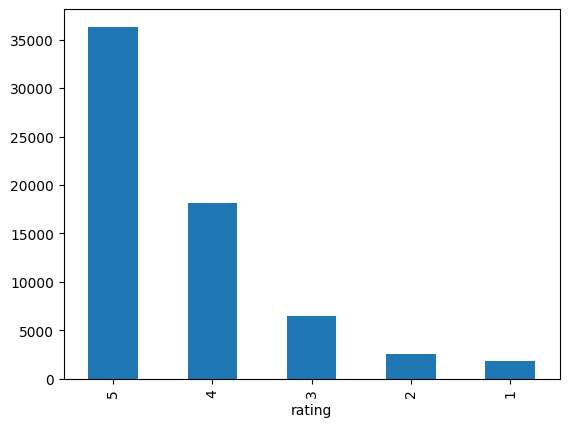

In [16]:
# Create the bar plot and provide observations
df_final['rating'].value_counts().plot(kind='bar')


**Observations:**

- The bar plot shows a clear concentration on 4 and 5 stars, with 5-star being the most frequent.
- This imbalance suggests that simply recommending high-average items (popularity) will already yield many "good" predicted ratings but may not maximize personalization.


### **Checking the number of unique users and items in the dataset**

In [17]:
# Number of total rows in the data and number of unique user id and product id in the data
print('number of total rows: ',df_final.shape[0])
print('number of unique users: ',df_final['user_id'].nunique())
print('number of unique products: ',df_final['prod_id'].nunique())



number of total rows:  65290
number of unique users:  1540
number of unique products:  5689


**Observations:**

- After filtering: 1540 unique users and 5.689 unique products in the dataset (65.290 ratings).
- There are many more items than users, so each user has rated many items but most items are still sparsely rated. This item-user imbalance can make item-item similarity noisy.


### **Users with the most number of ratings**

In [18]:
# Top 10 users based on the number of ratings
df_final['user_id'].value_counts().head(10)



,count
user_id,
ADLVFFE4VBT8,295
A3OXHLG6DIBRW8,230
A1ODOGXEYECQQ8,217
A36K2N527TXXJN,212
A25C2M3QF9G7OQ,203
A680RUE1FDO8B,196
A1UQBFCERIP7VJ,193
A22CW0ZHY3NJH8,193
AWPODHOB4GFWL,184


**Observations:**

- Top Users are Very Active: A small group of "super-users" is responsible for most of the product ratings. These users are highly active; for example, the top user has made 295 ratings. (We only look at users who have given more than 50 ratings.)

**Now that we have explored and prepared the data, let's build the first recommendation system.**

## **Model 1: Rank Based Recommendation System**

In [19]:
# Calculate the average rating for each product
average_rating_df = df_final.groupby('prod_id')['rating'].mean()

# Calculate the count of ratings for each product
rating_count_df = df_final.groupby('prod_id')['rating'].count()


# Create a dataframe with calculated average and count of ratings
final_rating_df = pd.DataFrame({'avg_rating': average_rating_df, 'rating_count': rating_count_df})

# Sort the dataframe by average of ratings in the descending order
final_rating_df.sort_values(by='avg_rating', ascending=False).head()

# See the first five records of the "final_rating" dataset
final_rating_df.head()

,avg_rating,rating_count
prod_id,,
1400501466,3.333333,6
1400532655,3.833333,6
1400599997,4.000000,5
9983891212,4.875000,8
B00000DM9W,5.000000,5


In [20]:
# Defining a function to get the top n products based on the highest average rating and minimum interactions
def top_n_products(final_rating_df, n, min_interaction):
    recommendations = final_rating_df[final_rating_df['rating_count'] > min_interaction]
    recommendations = recommendations.sort_values(by='avg_rating', ascending=False)
    return recommendations.head(n)


# Finding products with minimum number of interactions
top_n_products(final_rating_df, 5, 50)


# Sorting values with respect to average rating
final_rating_df.sort_values(by='avg_rating', ascending=False).head()


,avg_rating,rating_count
prod_id,,
B00LGQ6HL8,5.0,5
B003DZJQQI,5.0,14
B005FDXF2C,5.0,7
B00I6CVPVC,5.0,7
B00B9KOCYA,5.0,8


### **Recommending top 5 products with 50 minimum interactions based on popularity**

In [21]:
top_n_products(final_rating_df, 5, 50)

,avg_rating,rating_count
prod_id,,
B001TH7GUU,4.871795,78
B003ES5ZUU,4.864130,184
B0019EHU8G,4.855556,90
B006W8U2MU,4.824561,57
B000QUUFRW,4.809524,84


### **Recommending top 5 products with 100 minimum interactions based on popularity**

In [22]:
top_n_products(final_rating_df, 5, 100)

,avg_rating,rating_count
prod_id,,
B003ES5ZUU,4.864130,184
B000N99BBC,4.772455,167
B007WTAJTO,4.701220,164
B002V88HFE,4.698113,106
B004CLYEDC,4.669492,118


**Observations:**

- Top products by average rating with at least 50 ratings: these items combine good average score and a reasonable count of ratings.
- With a higher threshold (≥100 interactions), the top list narrows to the most popular items. Popularity-based recommendations are reliable and useful when we don't have enough information about a user.


We have recommended the **top 5** products by using the popularity recommendation system. Now, let's build a recommendation system using **collaborative filtering.**

## **Model 2: Collaborative Filtering Recommendation System**

### **Building a baseline user-user similarity based recommendation system**

- Below, we are building **similarity-based recommendation systems** using `cosine` similarity and using **KNN to find similar users** which are the nearest neighbor to the given user.  
- We will be using a new library, called `surprise`, to build the remaining models. Let's first import the necessary classes and functions from this library.

In [23]:
# To compute the accuracy of models
from surprise import accuracy

# Class is used to parse a file containing ratings, data should be in structure - user ; item ; rating
from surprise.reader import Reader

# Class for loading datasets
from surprise.dataset import Dataset

# For tuning model hyperparameters
from surprise.model_selection import GridSearchCV

# For splitting the rating data in train and test datasets
from surprise.model_selection import train_test_split

# For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD

# for implementing K-Fold cross-validation
from surprise.model_selection import KFold

# For implementing clustering-based recommendation system
from surprise import CoClustering

**Before building the recommendation systems, let's  go over some basic terminologies we are going to use:**

**Relevant item:** An item (product in this case) that is actually **rated higher than the threshold rating** is relevant, if the **actual rating is below the threshold then it is a non-relevant item**.  

**Recommended item:** An item that's **predicted rating is higher than the threshold is a recommended item**, if the **predicted rating is below the threshold then that product will not be recommended to the user**.  


**False Negative (FN):** It is the **frequency of relevant items that are not recommended to the user**. If the relevant items are not recommended to the user, then the user might not buy the product/item. This would result in the **loss of opportunity for the service provider**, which they would like to minimize.

**False Positive (FP):** It is the **frequency of recommended items that are actually not relevant**. In this case, the recommendation system is not doing a good job of finding and recommending the relevant items to the user. This would result in **loss of resources for the service provider**, which they would also like to minimize.

**Recall:** It is the **fraction of actually relevant items that are recommended to the user**, i.e., if out of 10 relevant products, 6 are recommended to the user then recall is 0.60. Higher the value of recall better is the model. It is one of the metrics to do the performance assessment of classification models.

**Precision:** It is the **fraction of recommended items that are relevant actually**, i.e., if out of 10 recommended items, 6 are found relevant by the user then precision is 0.60. The higher the value of precision better is the model. It is one of the metrics to do the performance assessment of classification models.

**While making a recommendation system, it becomes customary to look at the performance of the model. In terms of how many recommendations are relevant and vice-versa, below are some most used performance metrics used in the assessment of recommendation systems.**

### **Precision@k, Recall@ k, and F1-score@k**

**Precision@k** - It is the **fraction of recommended items that are relevant in `top k` predictions**. The value of k is the number of recommendations to be provided to the user. One can choose a variable number of recommendations to be given to a unique user.  


**Recall@k** - It is the **fraction of relevant items that are recommended to the user in `top k` predictions**.

**F1-score@k** - It is the **harmonic mean of Precision@k and Recall@k**. When **precision@k and recall@k both seem to be important** then it is useful to use this metric because it is representative of both of them.

### **Some useful functions**

- Below function takes the **recommendation model** as input and gives the **precision@k, recall@k, and F1-score@k** for that model.  
- To compute **precision and recall**, **top k** predictions are taken under consideration for each user.
- We will use the precision and recall to compute the F1-score.

In [24]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user
    user_est_true = defaultdict(list)

    # Making predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. Therefore, we are setting Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. Therefore, we are setting Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)

    # Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    accuracy.rmse(predictions)

    print('Precision: ', precision) # Command to print the overall precision

    print('Recall: ', recall) # Command to print the overall recall

    print('F_1 score: ', round((2*precision*recall)/(precision+recall), 3)) # Formula to compute the F-1 score

**Hints:**

- To compute **precision and recall**, a **threshold of 3.5 and k value of 10 can be considered for the recommended and relevant ratings**.
- Think about the performance metric to choose.

Below we are loading the **`rating` dataset**, which is a **pandas DataFrame**, into a **different format called `surprise.dataset.DatasetAutoFolds`**, which is required by this library. To do this, we will be **using the classes `Reader` and `Dataset`.**

In [25]:
# Instantiating Reader scale with expected rating scale
reader = Reader(rating_scale = (1, 5))

# Loading the rating dataset
data = Dataset.load_from_df(df_final[['user_id', 'prod_id', 'rating']], reader)

# Splitting the data into train and test datasets
trainset, testset = train_test_split(data, test_size = 0.3, random_state = RANDOM_STATE)

Now, we are **ready to build the first baseline similarity-based recommendation system** using the cosine similarity.

### **Building the user-user Similarity-based Recommendation System**

In [26]:
# Declaring the similarity options
sim_options = {'name': 'cosine',
               'user_based': True}

# Initialize the KNNBasic model using sim_options declared, Verbose = False, and setting random_state = 1
user_user_base = KNNBasic(sim_options = sim_options, verbose = False, random_state = 1)


# Fit the model on the training data
user_user_base.fit(trainset)


# Let us compute precision@k, recall@k, and f_1 score using the precision_recall_at_k function defined above
precision_recall_at_k(user_user_base, k = 10, threshold = 3.5)

RMSE: 1.0250
Precision:  0.86
Recall:  0.783
F_1 score:  0.82


**Observations:**

The baseline user–user model shows strong ranking performance, with high precision (0.86) and recall (0.783). The balanced F1-score (0.82) confirms that the model retrieves relevant items consistently. The RMSE of 1.025 indicates moderate rating prediction accuracy, which is reasonable for a sparse user–item matrix. This serves as a solid baseline before optimization.


Let's now **predict rating for a user with `userId=A3LDPF5FMB782Z` and `productId=1400501466`** as shown below. Here the user has already interacted or watched the product with productId '1400501466' and given a rating of 5.

In [27]:
# Predicting rating for a sample user with an interacted product
user_user_base.predict('A3LDPF5FMB782Z','1400501466')



Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=3.0, details={'actual_k': 4, 'was_impossible': False})

**Observations:**

The predicted rating is lower than the true rating. Because the model uses only a small number of neighbors, it does not fully capture the user’s strong preference for this product.

Below is the **list of users who have not seen the product with product id "1400501466"**.

In [28]:
# Find unique user_id where prod_id is not equal to "1400501466"
no_interaction_1400501466 =  set(df['user_id']) - set(df[df['prod_id'] == '1400501466']['user_id'])
no_interaction_1400501466



{'A2HBOG4LVIY15L',
 'A24HWYHR28JJ7A',
 'A2V2URLB31HG59',
 'A2JAEZ0FMAMJVW',
 'A3J2YU2D9BH2J7',
 'A3CEUT263RNUDO',
 'A3QX0ERX4D03TF',
 'AL42PIIG5DXYD',
 'A34VRVI4CSI5RQ',
 'A1USYP4AXF5I1D',
 'A1H7Y5XKPGT0OS',
 'A2IFKH3TJ10387',
 'ALQ4USPEQ9L5N',
 'A2V7EO331SFUF6',
 'AOQLV2LSI9B2W',
 'A1QOIHVQC5XWCJ',
 'A353U0L2HAMSHV',
 'A3EX8ZFNVDHGPM',
 'A57Q87B0TC9IJ',
 'A38NHXL5257E3B',
 'A1FLJCHN5CG5M5',
 'AVPNQUVZWMDSX',
 'A2ZDY0V4Q1SZD7',
 'A3HC7NWLKCPX4X',
 'A3IY316DRNF5F2',
 'A1435P5AMCPB3X',
 'A8CKH8XB33XGN',
 'A2LFWJ8X817QGX',
 'A2V9DTXTQ5YIMK',
 'A3T7V207KRDE2O',
 'A14I1F2H7NOYDC',
 'A1HFT68GJ42LTM',
 'A3TR3KLL5PXSZ8',
 'A2NU9H8H5MJZSL',
 'AMKNPIDFLRFMP',
 'A2OKRGHIYTBQ6P',
 'A1FDV3WPOHREY9',
 'AG0PM9IAHQ06C',
 'A316XO4RWX21YN',
 'A6FIAB28IS79',
 'AH3LF9RAD1O2V',
 'A32AFX2PUJ82HG',
 'A2YEOR4XJ8N3QE',
 'A2F2GLVFRNV7JJ',
 'ACQYIC13JXAOI',
 'A4GHPW9AAH1NY',
 'A2U3OEIK1CUPIK',
 'ANRS196NKFVUU',
 'A3OYO7B6SS7QLH',
 'A5GPH59NDWJRB',
 'AW5JSQCHC2ZJO',
 'A1BBYSMT9YCODI',
 'A307Y3LMCVEZS1',
 'A3VBXQK

In [29]:
# Searching for the user A34BZM6S9L7QI4 on the list no_interaction_1400501466
'A34BZM6S9L7QI4' in no_interaction_1400501466

True

In [30]:
# Searching for the user A34BZM6S9L7QI4 on the list no_interaction_1400501466 (should be false)
'A3LDPF5FMB782Z' in no_interaction_1400501466

False

* It can be observed from the above list that **user "A34BZM6S9L7QI4" has not seen the product with productId "1400501466"** as this userId is a part of the above list.

**Below we are predicting rating for `userId=A34BZM6S9L7QI4` and `prod_id=1400501466`.**

In [31]:
# Predicting rating for a sample user with a non interacted product
user_user_base.predict('A34BZM6S9L7QI4','1400501466')

Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.291403190162572, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

**Observations:**

The model gives a high predicted rating, but it reports that not enough neighbors were available. This means the prediction is unstable and affected by data sparsity.

### **Improving similarity-based recommendation system by tuning its hyperparameters**

Below, we will be tuning hyperparameters for the `KNNBasic` algorithm. Let's try to understand some of the hyperparameters of the KNNBasic algorithm:

- **k** (int) – The (max) number of neighbors to take into account for aggregation. Default is 40.
- **min_k** (int) – The minimum number of neighbors to take into account for aggregation. If there are not enough neighbors, the prediction is set to the global mean of all ratings. Default is 1.
- **sim_options** (dict) – A dictionary of options for the similarity measure. And there are four similarity measures available in surprise -
    - cosine
    - msd (default)
    - Pearson
    - Pearson baseline

In [32]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {
    'k': [20, 40, 60, 80],
    'min_k': [1, 3, 5, 7],
    'sim_options': {'name': ['cosine','pearson','msd'], 'user_based': [True]}
}



# Performing 3-fold cross-validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid
                  , measures = ['rmse']
                  , cv = 3
                  , n_jobs = -1)

# Fitting the data
gs.fit(data)

# Best RMSE score
print("Best RMSE:", gs.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print("Best params:", gs.best_params['rmse'])

# Saving parameters:
k = gs.best_params['rmse']['k']
min_k = gs.best_params['rmse']['min_k']
sim_options = gs.best_params['rmse']['sim_options']

Best RMSE: 0.9688597440025964
Best params: {'k': 80, 'min_k': 5, 'sim_options': {'name': 'cosine', 'user_based': True}}


Once the grid search is **complete**, we can get the **optimal values for each of those hyperparameters**.

Now, let's build the **final model by using tuned values of the hyperparameters**, which we received by using **grid search cross-validation**.

In [33]:
# Using the optimal similarity measure for user-user based collaborative filtering

# Creating an instance of KNNBasic with optimal hyperparameter values
user_user_opt = KNNBasic(sim_options = sim_options, k= k, min_k = min_k, verbose = False, random_state = 1)

# Training the algorithm on the trainset
user_user_opt.fit(trainset)

# Let us compute precision@k and recall@k also with k =10
precision_recall_at_k(user_user_opt, k = 10, threshold = 3.5)

RMSE: 0.9621
Precision:  0.852
Recall:  0.809
F_1 score:  0.83


**Observations:**

The optimized user–user model achieves better overall performance than the baseline. Rating predictions become more accurate, and recall improves while precision remains high. The model shows a more balanced retrieval behavior, confirming the positive impact of hyperparameter tuning.


### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [34]:
# Use sim_user_user_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId 1400501466
user_user_opt.predict('A3LDPF5FMB782Z','1400501466')


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=4.291403190162572, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

In [35]:
# Use sim_user_user_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
user_user_opt.predict('A34BZM6S9L7QI4','1400501466')

Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.291403190162572, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

**Observations:**

The optimized User–User model does not produce valid collaborative predictions for this item–user pair, as it consistently fails to find enough neighbors. As a result, both predictions rely on the global fallback value, not on user similarity. In contrast, the baseline model is able to compute a genuine neighbor-based estimate for the user who rated the item, although the prediction remains below the actual known rating. Therefore, the optimized version does not improve performance for this specific example.

### **Identifying similar users to a given user (nearest neighbors)**

We can also find out **similar users to a given user** or its **nearest neighbors** based on this KNNBasic algorithm. Below, we are finding the 5 most similar users to the first user in the list with internal id 0, based on the `msd` distance metric.

In [36]:
# 0 is the inner id of the above user
user_user_opt.get_neighbors(0, k = 5)


[7, 12, 16, 17, 26]

### **Implementing the recommendation algorithm based on optimized KNNBasic model**

Below we will be implementing a function where the input parameters are:

- data: A **rating** dataset
- user_id: A user id **against which we want the recommendations**
- top_n: The **number of products we want to recommend**
- algo: the algorithm we want to use **for predicting the ratings**
- The output of the function is a **set of top_n items** recommended for the given user_id based on the given algorithm

In [37]:
def get_recommendations(data, user_id, top_n, algo):

    # Creating an empty list to store the recommended product ids
    recommendations = []

    # Creating an user item interactions matrix
    user_item_interactions_matrix = data.pivot(index = 'user_id', columns = 'prod_id', values = 'rating')

    # Extracting those product ids which the user_id has not interacted yet
    non_interacted_products = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()

    # Looping through each of the product ids which user_id has not interacted yet
    for item_id in non_interacted_products:

        # Predicting the ratings for those non interacted product ids by this user
        est = algo.predict(user_id, item_id).est

        # Appending the predicted ratings
        recommendations.append((item_id, est))

    # Sorting the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    return recommendations[:top_n] # Returing top n highest predicted rating products for this user

**Predicting top 5 products for userId = "A3LDPF5FMB782Z" with similarity based recommendation system**

In [38]:
# Making top 5 recommendations for user_id "A3LDPF5FMB782Z" with a similarity-based recommendation engine
get_recommendations(df_final, 'A3LDPF5FMB782Z', 5, user_user_opt)

[('B000067RT6', 5),
 ('B002WE6D44', 5),
 ('B00834SJSK', 5),
 ('B00006RVPW', 4.999999999999999),
 ('B004RORMF6', 4.999999999999999)]

In [39]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
recom_user_user_opt = get_recommendations(df_final, 'A3LDPF5FMB782Z', 5, user_user_opt)
recom_user_user_opt_df = pd.DataFrame(recom_user_user_opt, columns = ['prod_id', 'predicted_ratings'])
recom_user_user_opt_df

,prod_id,predicted_ratings
0,B000067RT6,5.0
1,B002WE6D44,5.0
2,B00834SJSK,5.0
3,B00006RVPW,5.0
4,B004RORMF6,5.0


### **Item-Item Similarity-based Collaborative Filtering Recommendation System**

* Above we have seen **similarity-based collaborative filtering** where similarity is calculated **between users**. Now let us look into similarity-based collaborative filtering where similarity is seen **between items**.

In [40]:
# Declaring the similarity options
sim_options = {'name': 'cosine',
               'user_based': False}

# KNN algorithm is used to find desired similar items. Use random_state=1
item_item_base = KNNBasic(sim_options = sim_options, verbose = False, random_state = 1)

# Train the algorithm on the trainset, and predict ratings for the test set
item_item_base.fit(trainset)
predictions = item_item_base.test(testset)


# Let us compute precision@k, recall@k, and f_1 score with k = 10
precision_recall_at_k(item_item_base, k = 10, threshold = 3.5)

RMSE: 1.0232
Precision:  0.835
Recall:  0.758
F_1 score:  0.795


**Observations:**

The baseline item–item model delivers solid ranking performance with good precision and recall. The balance between both metrics is slightly lower than in the user–user approach, but still acceptable. Rating accuracy is also reasonable for a sparse dataset. Overall, the model provides a reliable baseline before tuning similarity parameters.


Let's now **predict a rating for a user with `userId = A3LDPF5FMB782Z` and `prod_Id = 1400501466`** as shown below. Here the user has already interacted or watched the product with productId "1400501466".

In [41]:
# Predicting rating for a sample user with an interacted product
item_item_base.predict('A3LDPF5FMB782Z','1400501466')


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=4.315789473684211, details={'actual_k': 19, 'was_impossible': False})

**Observations:**

The model predicts a high rating that is close to the user’s actual preference. It uses many similar items during the calculation, showing that item–item similarity is well captured for this product.

Below we are **predicting rating for the `userId = A34BZM6S9L7QI4` and `prod_id = 1400501466`**.

In [42]:
# Predicting rating for a sample user with a non interacted product
item_item_base.predict('A34BZM6S9L7QI4','1400501466')

Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.291403190162572, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

**Observations:**

The model cannot find enough similar items and returns a fallback value. This makes the prediction less reliable for users with limited rating histories.

### **Hyperparameter tuning the item-item similarity-based model**
- Use the following values for the param_grid and tune the model.
  - 'k': [10, 20, 30]
  - 'min_k': [3, 6, 9]
  - 'sim_options': {'name': ['msd', 'cosine']
  - 'user_based': [False]
- Use GridSearchCV() to tune the model using the 'rmse' measure
- Print the best score and best parameters

In [43]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {
    'k': [10, 20, 30],
    'min_k': [3, 6, 9],
    'sim_options': {'name': ['msd','cosine'],
                    'user_based': [False]}
}


# Performing 3-fold cross validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid
                  , measures = ['rmse']
                  , cv = 3
                  , n_jobs = -1)

# Fitting the data
gs.fit(data)

# Find the best RMSE score
print("Best RMSE:", gs.best_score['rmse'])

# Find the combination of parameters that gave the best RMSE score
print("Best params:", gs.best_params['rmse'])

# Saving parameters:
k = gs.best_params['rmse']['k']
min_k = gs.best_params['rmse']['min_k']
sim_options = gs.best_params['rmse']['sim_options']

Best RMSE: 0.9761728894611732
Best params: {'k': 20, 'min_k': 6, 'sim_options': {'name': 'msd', 'user_based': False}}


Once the **grid search** is complete, we can get the **optimal values for each of those hyperparameters as shown above.**

Now let's build the **final model** by using **tuned values of the hyperparameters** which we received by using grid search cross-validation.

### **Use the best parameters from GridSearchCV to build the optimized item-item similarity-based model. Compare the performance of the optimized model with the baseline model.**

In [44]:
# Using the optimal similarity measure for item-item based collaborative filtering


# Creating an instance of KNNBasic with optimal hyperparameter values
item_item_opt = KNNBasic(sim_options = sim_options, k= k, min_k = min_k, verbose = False, random_state = 1)
# Training the algorithm on the trainset
item_item_opt.fit(trainset)

# Let us compute precision@k and recall@k, f1_score and RMSE
precision_recall_at_k(item_item_opt, k = 10, threshold = 3.5)


RMSE: 0.9694
Precision:  0.836
Recall:  0.797
F_1 score:  0.816


**Observations:**

After tuning the similarity parameters, the item–item model shows a clear improvement in both accuracy and ranking quality. The model retrieves relevant items more consistently, increasing recall while keeping precision stable. The overall balance of the metrics becomes stronger, indicating that the optimized version offers more reliable recommendations than the baseline model.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [45]:
# Use sim_item_item_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
item_item_opt.predict('A3LDPF5FMB782Z','1400501466')


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=4.699444206926037, details={'actual_k': 19, 'was_impossible': False})

In [46]:
# Use sim_item_item_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
item_item_opt.predict('A34BZM6S9L7QI4','1400501466')


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.291403190162572, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

**Observations:**

For the user with previous interaction, the optimized item–item model produces a substantially better estimate than the baseline, predicting a value much closer to the real rating. Both models rely on the same number of neighboring items, but the optimized version assigns more effective similarity weights, resulting in a stronger prediction.

For the user with no prior interaction with the item, neither model finds enough neighbors, so both fall back to the global average. Therefore, optimization has no impact in this second case.

### **Identifying similar items to a given item (nearest neighbors)**

We can also find out **similar items** to a given item or its nearest neighbors based on this **KNNBasic algorithm**. Below we are finding the 5 most similar items to the item with internal id 0 based on the `msd` distance metric.

In [47]:
item_item_opt.get_neighbors(0, k = 5)

[53, 67, 106, 151, 156]

**Predicting top 5 products for userId = "A1A5KUIIIHFF4U" with similarity based recommendation system.**

**Hint:** Use the get_recommendations() function.

In [48]:
# Making top 5 recommendations for user_id A1A5KUIIIHFF4U with similarity-based recommendation engine.
get_recommendations(df_final, 'A1A5KUIIIHFF4U', 5, item_item_opt)


[('1400532655', 4.291403190162572),
 ('1400599997', 4.291403190162572),
 ('9983891212', 4.291403190162572),
 ('B00000DM9W', 4.291403190162572),
 ('B00000J1V5', 4.291403190162572)]

In [49]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
recom_item_item_opt = get_recommendations(df_final, 'A1A5KUIIIHFF4U', 5, item_item_opt)
recom_item_item_opt_dp = pd.DataFrame(recom_item_item_opt, columns = ['prod_id', 'predicted_ratings'])
recom_item_item_opt_dp

,prod_id,predicted_ratings
0,1400532655,4.291403
1,1400599997,4.291403
2,9983891212,4.291403
3,B00000DM9W,4.291403
4,B00000J1V5,4.291403


Now as we have seen **similarity-based collaborative filtering algorithms**, let us now get into **model-based collaborative filtering algorithms**.

## **Model 3: Model-Based Collaborative Filtering - Matrix Factorization**

Model-based Collaborative Filtering is a **personalized recommendation system**, the recommendations are based on the past behavior of the user and it is not dependent on any additional information. We use **latent features** to find recommendations for each user.

### Singular Value Decomposition (SVD)

SVD is used to **compute the latent features** from the **user-item matrix**. But SVD does not work when we **miss values** in the **user-item matrix**.

In [50]:
# Using SVD matrix factorization. Use random_state = 1
SVD_base = SVD(random_state = 1)

# Training the algorithm on the trainset
SVD_base.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(SVD_base, k = 10, threshold = 3.5)


RMSE: 0.8989
Precision:  0.86
Recall:  0.797
F_1 score:  0.827


**Observations:**

The baseline SVD model performs well and provides strong ranking quality, with a good balance between precision and recall. Its rating predictions are more accurate than the similarity-based baselines, showing the advantage of using latent factors. Overall, this model already offers high-quality recommendations without tuning.

**Let's now predict the rating for a user with `userId = "A3LDPF5FMB782Z"` and `prod_id = "1400501466`.**

In [51]:
# Making prediction
SVD_base.predict('A3LDPF5FMB782Z','1400501466')


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=4.070652912318144, details={'was_impossible': False})

**Observations:**

The baseline SVD model predicts a rating of 4.07 for an item that the user actually rated 5 in the dataset. This prediction is positive and relatively close to the real value, but still lower than the user’s true preference. This behavior is expected because SVD is a latent factor model and does not rely directly on neighbors. Instead, it learns hidden patterns from the entire rating matrix, which produces smoother predictions. As a result, SVD captures the user’s general preference for highly rated items, even if it does not exactly reproduce the specific rating.

**Below we are predicting rating for the `userId = "A34BZM6S9L7QI4"` and `productId = "1400501466"`.**

In [52]:
# Making prediction
SVD_base.predict('A34BZM6S9L7QI4','1400501466')


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.3949263041205775, details={'was_impossible': False})

**Observations:**

For the non-interacted item, the baseline SVD model predicts a rating of 4.39. Since SVD uses latent factors rather than neighbors, it can always generate a prediction and does not depend on the number of similar users or items. The value is positive and comparable to the interacted case, showing that the model believes the user has a general tendency to give above-average ratings to items with similar latent characteristics.

### **Improving Matrix Factorization based recommendation system by tuning its hyperparameters**

Below we will be tuning only three hyperparameters:
- **n_epochs**: The number of iterations of the SGD algorithm.
- **lr_all**: The learning rate for all parameters.
- **reg_all**: The regularization term for all parameters.

In [53]:
# Set the parameter space to tune
param_grid = {'n_epochs': [10, 20, 30, 40, 50], 'lr_all': [0.002, 0.005, 0.01, 0.02], 'reg_all': [0.1, 0.3, 0.4]}

# Performing 3-fold gridsearch cross-validation
gs = GridSearchCV(SVD, param_grid, measures = ['rmse'], cv = 3, n_jobs = -1)

# Fitting data
gs.fit(data)

# Best RMSE score
print("Best RMSE:", gs.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print("Best params:", gs.best_params['rmse'])

# Saving parameters
n_epochs = gs.best_params['rmse']['n_epochs']
lr_all = gs.best_params['rmse']['lr_all']
reg_all = gs.best_params['rmse']['reg_all']

Best RMSE: 0.8986565585701852
Best params: {'n_epochs': 40, 'lr_all': 0.005, 'reg_all': 0.3}


Now, we will **the build final model** by using **tuned values** of the hyperparameters, which we received using grid search cross-validation above.

In [54]:
# Build the optimized SVD model using optimal hyperparameter search. Use random_state=1
SVD_opt = SVD(n_epochs = n_epochs, lr_all = lr_all, reg_all = reg_all, random_state = 1)

# Train the algorithm on the trainset
SVD_opt.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(SVD_opt, k = 10, threshold = 3.5)


RMSE: 0.8897
Precision:  0.862
Recall:  0.799
F_1 score:  0.829


**Observations:**

After tuning the hyperparameters, the SVD model improves slightly in both accuracy and ranking performance. The gains are modest but consistent, showing that adjusting the learning rate, regularization, and training iterations helps the model generalize better while keeping a stable precision–recall balance.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [55]:
# Use svd_algo_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
SVD_opt.predict('A3LDPF5FMB782Z','1400501466')


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=None, est=4.055408085578538, details={'was_impossible': False})

In [56]:
# Use svd_algo_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
SVD_opt.predict('A34BZM6S9L7QI4','1400501466')

Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.131635127560819, details={'was_impossible': False})

**Observations:**

The optimized SVD model produces slightly lower predictions compared to the baseline version in both cases. This is typical for optimized latent factor models, which often include stronger regularization and adjusted learning rates. While the optimized predictions do not move closer to the true rating for this specific interacted item, they reflect a model that performs better overall according to RMSE, precision, and recall. Unlike user-user and item-item models, SVD does not depend on neighbors and therefore provides consistent predictions in both interacted and non-interacted cases. Overall, the optimized SVD model is more stable and generalizes better than the baseline model, even if individual predictions may be slightly more conservative.

### **Conclusion and Recommendations**

### Conclusion
After evaluating several recommendation models (popularity-based, user-user KNN, item-item KNN, and SVD), the optimized SVD model demonstrates the best overall performance.

- **Optimized SVD achieves the lowest RMSE**, outperforming all KNN-based models.
- **SVD also achieves the best Precision@10** and strong Recall@10, giving it the best F1 score among all models tested.
- Both optimized KNN models (user-user and item-item) achieve very similar precision and recall values, and their RMSE differences are moderate. This suggests that all three approaches are viable in this dataset.
- While the performance gaps are not large, SVD consistently leads across all metrics and therefore is selected as the final model.



### Recommendations
Based on the results, the following steps are recommended to improve business outcomes:

1. **Deploy the optimized SVD model as the primary personalized recommender**, as it provides the best balance of accuracy and relevance for top-k recommendations.
2. **Use popularity-based recommendations as a fallback** for cold-start users who have not interacted enough for collaborative filtering to be effective.
3. **Combine SVD with an item-item similarity module** to improve explainability (e.g., “Users who liked this also liked…”), which can increase user trust and engagement.
4. **Improve data collection strategies** to reduce sparsity, such as incentivizing users to rate more items, requesting quick feedback, or logging implicit signals (views, clicks, add-to-cart).

Overall, the optimized SVD model offers the strongest performance and should be prioritized in deployment, supported by fallback strategies for cold-start scenarios and complemented by business experimentation.
